In [1]:
# Data hosted at below link (downloading it)
# This command uses `wget` to download a zipped archive file from a Dropbox URL.
# The `!` at the beginning indicates that it's a shell command executed from the notebook.
!wget https://www.dropbox.com/s/tlxserrdhe240lu/archive.zip

# Unzipping the data
# This command uses `unzip` to extract the contents of the downloaded `archive.zip` file.
# The `-q` flag makes the unzip process quiet, meaning it won't print every file it extracts.
!unzip -q "archive.zip"

--2026-07-28 21:28:38--  https://www.dropbox.com/s/tlxserrdhe240lu/archive.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/yzldvhixewlfrtdatr3m9/archive.zip?rlkey=azh4epb0r6uqwe1vh74jctsnh [following]
--2026-07-28 21:28:38--  https://www.dropbox.com/scl/fi/yzldvhixewlfrtdatr3m9/archive.zip?rlkey=azh4epb0r6uqwe1vh74jctsnh
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc67a1f65f8ee8f551e2429f999d.dl.dropboxusercontent.com/cd/0/inline/DFJj5fjzB_qq4PPMyy-hpqkhV1tWl2CNG2f4GNY1v3JIDF6ogYfv4oE2G3rqZwFmBHA_xuqCuU9-UKBl0PsRPlUJJbYcXI2KTQvRIXIoxD-4bH3RLi2j4z-w9v35yeb6c_4Um_a9m5a8kkKsa2qwV6CW/file# [following]
--2026-07-28 21:28:39--  https://uc67a1f65f8ee8f551e2429f999d.dl.dropboxusercontent.com/cd/0/inline/DFJj

In [2]:
# Imports required for this project
# Importing the TensorFlow library, which is a powerful open-source machine learning framework.
import tensorflow as tf
# Importing NumPy for numerical operations, especially for working with arrays.
import numpy as np
# Importing Matplotlib's pyplot module for plotting and visualization.
import matplotlib.pyplot as plt
# Importing Path from pathlib for working with file system paths in an object-oriented way.
from pathlib import Path

# Setting a random seed for TensorFlow. This ensures that any random operations (like weight initialization)
# in TensorFlow will produce the same results every time the code is run, making experiments reproducible.
tf.random.set_seed(4)

In [3]:
# Creating the Pathlib PATH objects
# These lines define `Path` objects for the training, validation, and test datasets.
# `Path` objects provide a convenient way to interact with file paths (e.g., joining paths, checking existence).
# The paths point to specific directories where the chest X-ray images are stored.
train_path = Path("chest_xray/train/")
validation_path = Path("chest_xray/test") # Note: The original notebook used 'test' for validation
test_path = Path("chest_xray/val")       # Note: The original notebook used 'val' for testing

In [4]:
# Collecting all the Paths Inside "Normal" and "Pneumonia" folders of the above paths
# The `glob("*/*")` method on a Path object finds all files and directories matching the pattern.
# Here, it looks for any file or directory (first `*`) inside any subdirectory (second `*`)
# within `train_path` and `validation_path`. This effectively collects all image file paths.
train_image_paths = train_path.glob("*/*")
val_image_paths = validation_path.glob("*/*")

# Output is a Generator object
# `glob` returns a generator, which is memory-efficient as it yields one path at a time.
# We print it here to show its type before converting it to a list.
print(train_image_paths)

<generator object Path.glob at 0x7c7d27ec2790>


In [5]:
# Convert Generator Object to List of elements
# Convert the generator objects from `glob` into actual lists of Path objects.
# This makes it easier to work with them (e.g., slicing, checking length).
train_image_paths = list(train_image_paths)
val_image_paths = list(val_image_paths)

# Now the outputs are "PosixPath" objects
# Print the first three elements of the `train_image_paths` list to verify their type and content.
# `PosixPath` is an object representation of a file system path.
print(train_image_paths[:3])

[PosixPath('chest_xray/train/NORMAL/NORMAL2-IM-1337-0001.jpeg'), PosixPath('chest_xray/train/NORMAL/NORMAL2-IM-0797-0001.jpeg'), PosixPath('chest_xray/train/NORMAL/NORMAL2-IM-1044-0001.jpeg')]


In [6]:
# Convert Posix paths to normal strings
# The `tf.data.Dataset.from_tensor_slices` function works better with string paths.
# This line uses `map` with a `lambda` function to convert each `PosixPath` object in the lists
# to its string representation. This is crucial for TensorFlow to read the image files later.
train_image_paths = list(map(lambda x : str(x) , train_image_paths))
val_image_paths = list(map(lambda x : str(x) , val_image_paths))

# Print the first three elements again to show they are now strings.
print(train_image_paths[:3])

['chest_xray/train/NORMAL/NORMAL2-IM-1337-0001.jpeg', 'chest_xray/train/NORMAL/NORMAL2-IM-0797-0001.jpeg', 'chest_xray/train/NORMAL/NORMAL2-IM-1044-0001.jpeg']


In [7]:
# Collect Length for Training and Validation Datasets
# Get the total number of image paths for the training and validation sets.
# This will be used later for `steps_per_epoch` in model training.
train_dataset_length = len(train_image_paths)
val_dataset_length = len(val_image_paths)

In [8]:
# Every Image has Label in its path , so lets slice it
# Define a dictionary to map class names ('NORMAL', 'PNEUMONIA') to integer labels (0, 1).
LABELS = {'NORMAL' : 0 , 'PNEUMONIA' : 1}
# Define an inverse dictionary to map integer labels back to class names. Useful for displaying results.
INV_LABELS = {0 : 'NORMAL', 1 : 'PNEUMONIA'}

# Define a helper function to extract the label from an image file path.
# The label (e.g., 'NORMAL' or 'PNEUMONIA') is typically the second-to-last part of the path.
def get_label(path : str) -> int:
    # Splits the path by '/' and takes the second to last element (e.g., 'NORMAL').
    # Then, it uses the LABELS dictionary to convert this string to an integer (0 or 1).
    return LABELS[path.split("/")[-2]]

# Apply the `get_label` function to all training and validation image paths
# to create lists of their corresponding integer labels.
train_labels = list(map(lambda x : get_label(x) , train_image_paths))
val_labels = list(map(lambda x : get_label(x) , val_image_paths))

# Print the first three training labels to verify the extraction.
print(train_labels[:3])

[0, 0, 0]


In [9]:
# Now we have all training, validation image paths and their respective labels

# Define the batch size for training. This determines how many images are processed at once.
BATCH_SIZE = 32

# Function used for Transformation during training
# This function takes an image path, its label, and a `train` flag.
# It's responsible for loading the image, resizing it, and applying data augmentation (if training).
def load_and_transform(image , label , train = True):
    # Reads the image file from the given path as raw bytes.
    image = tf.io.read_file(image)
    # Decodes the JPEG image bytes into a tensor. `channels=3` means RGB.
    image = tf.io.decode_jpeg(image , channels = 3)
    # Resizes the image to 224x224 pixels using the 'nearest' interpolation method.
    # This is a common input size for many pre-trained deep learning models like ResNet.
    image = tf.image.resize(image , [224 , 224] , method="nearest")
    # If in training mode, randomly flip the image horizontally (left-right).
    # This is a data augmentation technique to increase the diversity of training data and prevent overfitting.
    if train:
        image = tf.image.random_flip_left_right(image)
    # Returns the processed image tensor and its corresponding label.
    return image , label

# Function used to Create a Tensorflow Data Object
# This function takes lists of image paths and labels and constructs a TensorFlow `tf.data.Dataset`.
# `tf.data` API is highly efficient for building data pipelines.
def get_dataset(paths , labels , train = True):
    # Converts the Python lists of paths and labels into TensorFlow tensors.
    image_paths = tf.convert_to_tensor(paths)
    labels = tf.convert_to_tensor(labels)

    # Creates a dataset where each element is a tuple of (image_path, label).
    image_dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    label_dataset = tf.data.Dataset.from_tensor_slices(labels)
    # Zips the image path dataset and label dataset together.
    # `shuffle(1000)` shuffles the initial buffer of 1000 elements to ensure randomness.
    dataset = tf.data.Dataset.zip((image_dataset , label_dataset)).shuffle(1000)

    # Applies the `load_and_transform` function to each (image_path, label) pair in the dataset.
    # This is where images are loaded, resized, and potentially augmented.
    dataset = dataset.map(lambda image , label : load_and_transform(image , label , train))
    # Repeats the dataset indefinitely. This is common for training loops to avoid running out of data.
    dataset = dataset.repeat()
    # Shuffles the entire dataset (or a large buffer of 2048 elements) again for better randomization.
    dataset = dataset.shuffle(2048)
    # Batches the dataset elements. Each iteration will yield a batch of `BATCH_SIZE` images and labels.
    dataset = dataset.batch(BATCH_SIZE)

    return dataset

In [10]:
# Creating Train Dataset object and Verifying it
# `%time` is an IPython magic command that measures the execution time of the line.
# Calls `get_dataset` to create the training dataset object.
%time train_dataset = get_dataset(train_image_paths , train_labels)

# Retrieves a single batch (image, label) from the `train_dataset`.
# `iter(train_dataset)` creates an iterator, and `next()` gets the first item.
image , label = next(iter(train_dataset))

# Prints the shape of the image batch and label batch.
# `(32, 224, 224, 3)` means 32 images, each 224x224 pixels with 3 color channels (RGB).
# `(32,)` means 32 labels, one for each image in the batch.
print(image.shape)
print(label.shape)

CPU times: user 1.58 s, sys: 461 ms, total: 2.04 s
Wall time: 3.82 s
(32, 224, 224, 3)
(32,)


PNEUMONIA


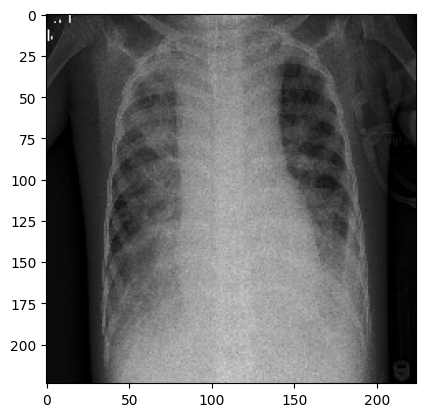

In [11]:
# View a sample Train Image
# Prints the human-readable label of the first image in the batch using `INV_LABELS`.
# `.numpy()` converts the TensorFlow tensor to a NumPy array.
print(INV_LABELS[label[0].numpy()])
# Displays the first image from the batch using Matplotlib.
# `.reshape(224, 224, 3)` ensures the image is correctly shaped for display if it was flattened or altered.
plt.imshow(image[0].numpy().reshape(224 , 224 , 3))

In [12]:
# Creating Validation Dataset object and Verifying it
# `%time` is an IPython magic command that measures the execution time of the line.
# Calls `get_dataset` to create the validation dataset object. `train=False` ensures no augmentation.
%time val_dataset = get_dataset(val_image_paths , val_labels , train = False)

# Retrieves a single batch (image, label) from the `val_dataset`.
image , label = next(iter(val_dataset))

# Prints the shape of the image batch and label batch for the validation set.
print(image.shape)
print(label.shape)

CPU times: user 25.1 ms, sys: 0 ns, total: 25.1 ms
Wall time: 25.8 ms
(32, 224, 224, 3)
(32,)


PNEUMONIA


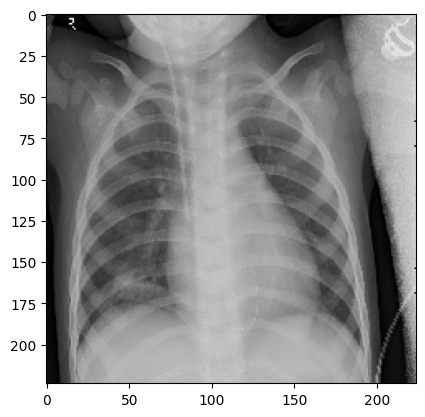

In [13]:
# View a sample Validation Image
# Prints the human-readable label of the first image in the validation batch.
print(INV_LABELS[label[0].numpy()])
# Displays the first image from the validation batch using Matplotlib.
plt.imshow(image[0].numpy().reshape(224 , 224 , 3))

In [14]:
# Building ResNet50 model
# Imports the ResNet50V2 pre-trained convolutional neural network model from Keras applications.
from tensorflow.keras.applications import ResNet50V2

# Initializes the ResNet50V2 model as the 'backbone' for our custom model.
# `input_shape=(224, 224, 3)` specifies the expected input image size (height, width, channels).
# `include_top=False` means we are excluding the fully connected (classification) layers at the top of ResNet50V2.
# We will add our own classification layers for our specific problem.
backbone = ResNet50V2(
    input_shape=(224, 224, 3),
    include_top=False
)

# Constructs a sequential Keras model (layers stacked one after another).
model = tf.keras.Sequential([
    # The pre-trained ResNet50V2 model without its top classification layers.
    backbone,
    # A GlobalAveragePooling2D layer reduces the spatial dimensions of the feature maps
    # by taking the average of each feature map. This prepares the output for the dense layer.
    tf.keras.layers.GlobalAveragePooling2D(),
    # A Dense (fully connected) layer with 1 unit and a 'sigmoid' activation function.
    # 'sigmoid' is used here because it's a binary classification problem (Pneumonia vs. Normal).
    # It outputs a probability between 0 and 1.
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Prints a summary of the model's architecture, including layer names, output shapes, and number of parameters.
model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 23,521,409 (89.73 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [15]:
# Compiling your model by providing the Optimizer , Loss and Metrics
# `model.compile` configures the model for training.
model.compile(
    # Optimizer: Adam is an efficient stochastic optimization algorithm.
    # `learning_rate` controls the step size during optimization.
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07),
    # Loss function: 'binary_crossentropy' is suitable for binary classification problems (two classes).
    # It measures the difference between the predicted probabilities and the true labels.
    loss = 'binary_crossentropy',
    # Metrics: These are used to monitor the training and evaluation process.
    # 'accuracy' measures the proportion of correctly classified samples.
    # `tf.keras.metrics.Precision` calculates the precision (true positives / (true positives + false positives)).
    # `tf.keras.metrics.Recall` calculates the recall (true positives / (true positives + false negatives)).
    metrics=['accuracy' , tf.keras.metrics.Precision(name='precision'),tf.keras.metrics.Recall(name='recall')]
)

In [16]:
# Defining our callbacks

# Callbacks are functions that can be applied at certain stages of the training procedure.
# ModelCheckpoint: Saves the model's weights during training.
# `"best_weights.weights.h5"`: Specifies the filename to save the weights.
# `verbose=1`: Prints messages when a checkpoint is saved.
# `save_best_only=True`: Only saves the weights if the monitored metric (validation loss by default) improves.
# `save_weights_only = True`: Only saves the model's weights, not the entire model architecture.
checkpoint = tf.keras.callbacks.ModelCheckpoint("best_weights.weights.h5",verbose=1,save_best_only=True,save_weights_only = True)
# EarlyStopping: Stops training when a monitored metric has stopped improving.
# `patience=4`: Training will stop if the monitored metric (validation loss by default) does not improve for 4 consecutive epochs.
early_stop = tf.keras.callbacks.EarlyStopping(patience=4)

In [17]:
# Train the model
# `model.fit` starts the training process.
# `train_dataset`: The dataset used for training.
# `steps_per_epoch`: The number of batches to draw from `train_dataset` per epoch.
# It's calculated as the total number of training samples divided by the batch size.
# `epochs=8`: The total number of times the model will iterate over the entire training dataset.
# `callbacks`: A list of callbacks to apply during training (e.g., saving best weights, early stopping).
# `validation_data`: The dataset used for evaluating the model after each epoch.
# `validation_steps`: The number of batches to draw from `val_dataset` for validation.
history = model.fit(
    train_dataset,
    steps_per_epoch=train_dataset_length//BATCH_SIZE,
    epochs=8,
    callbacks=[checkpoint , early_stop],
    validation_data=val_dataset,
    validation_steps = val_dataset_length//BATCH_SIZE,
)

Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9236 - loss: 0.2088 - precision: 0.9311 - recall: 0.9371
Epoch 1: val_loss improved from None to 15.54985, saving model to best_weights.weights.h5

Epoch 1: finished saving model to best_weights.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 176s 508ms/step - accuracy: 0.9436 - loss: 0.1639 - precision: 0.9556 - recall: 0.9595 - val_accuracy: 0.3701 - val_loss: 15.5498 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9616 - loss: 0.0990 - precision: 0.9739 - recall: 0.9726
Epoch 2: val_loss improved from 15.54985 to 3.80046, saving model to best_weights.weights.h5

Epoch 2: finished saving model to best_weights.weights.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 516ms/step - accuracy: 0.9688 - loss: 0.0870 - precision: 0.9787 - recall: 0.9790 - val_accuracy: 0.5181 - val_loss: 3.8005 - val_precision: 0.9560 - val_recall: 0.2314
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━

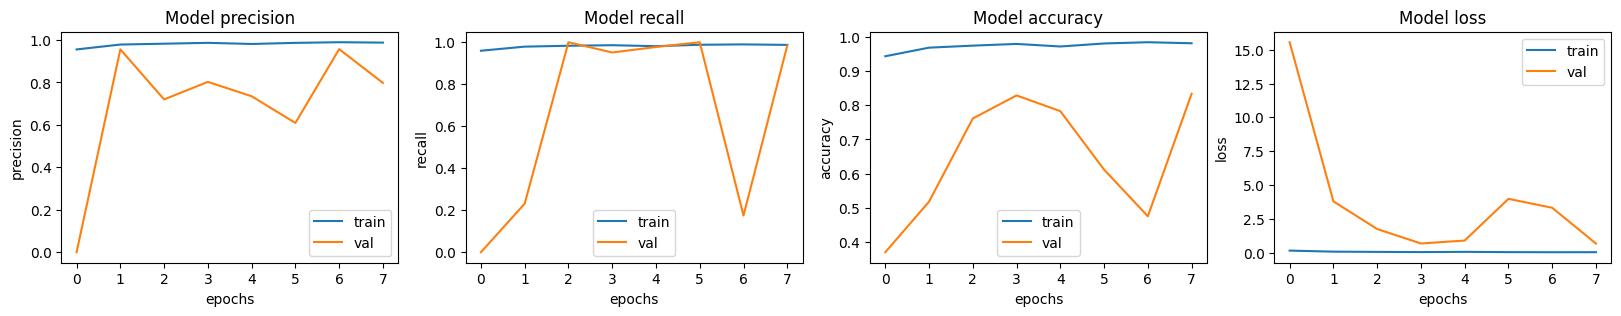

In [18]:
# Interpreting the Metrics
# Creates a figure and a set of subplots (1 row, 4 columns) for plotting training history.
fig, ax = plt.subplots(1, 4, figsize=(20, 3))
# Flattens the `ax` array for easy iteration.
ax = ax.ravel()

# Iterates through the metrics: precision, recall, accuracy, and loss.
for i, met in enumerate(['precision', 'recall', 'accuracy', 'loss']):
    # Plots the training values for the current metric.
    ax[i].plot(history.history[met])
    # Plots the validation values for the current metric.
    ax[i].plot(history.history['val_' + met])
    # Sets the title for the subplot.
    ax[i].set_title('Model {}'.format(met))
    # Sets the x-axis label.
    ax[i].set_xlabel('epochs')
    # Sets the y-axis label.
    ax[i].set_ylabel(met)
    # Adds a legend to distinguish between training and validation curves.
    ax[i].legend(['train', 'val'])

In [19]:
# Saving the best Model

# Load the best weights: Loads the weights that resulted in the best validation performance
# (as determined by the `ModelCheckpoint` callback) back into the model.
model.load_weights("best_weights.weights.h5")
# Save the whole model (weights + architecture): Saves the entire model (architecture, weights, and training configuration)
# to a single file in the Keras format (H5). This allows reloading the model later without rebuilding it.
model.save("model.keras")

In [20]:
# Loading the whole model
# Loads the entire model (architecture and weights) from the saved file.
# This allows using the trained model for prediction without retraining.
loaded_model = tf.keras.models.load_model("model.keras") # Corrected from model.h5 to model.keras based on save

### Create a Testing Dataset
This section focuses on preparing the data specifically for evaluating the model's performance on unseen data (the test set). The process is similar to creating the training and validation datasets, but without data augmentation.

In [21]:
# Create a Dataset Object for 'Testing' Set just the way we did for Training and Validation
# Collects all image paths from the 'val' directory (used as the test set).
test_image_paths = list(test_path.glob("*/*"))
# Converts the PosixPath objects to strings.
test_image_paths = list(map(lambda x : str(x) , test_image_paths))
# Extracts the labels for the test images.
test_labels = list(map(lambda x : get_label(x) , test_image_paths))

# Converts the lists of paths and labels into TensorFlow tensors.
test_image_paths = tf.convert_to_tensor(test_image_paths)
test_labels = tf.convert_to_tensor(test_labels)

# Defines a decoding function similar to `load_and_transform` but without augmentation.
# It reads the image file, decodes it, and resizes it to 224x224.
def decode_image(image , label):
    image = tf.io.read_file(image)
    image = tf.io.decode_jpeg(image , channels = 3)
    image = tf.image.resize(image , [224 , 224] , method="nearest")
    return image , label

# Creates the TensorFlow `tf.data.Dataset` for the test set.
# `from_tensor_slices`: Creates a dataset from tensors.
# `.map(decode_image)`: Applies the decoding and resizing function to each image.
# `.batch(BATCH_SIZE)`: Batches the images for efficient processing.
test_dataset = (
     tf.data.Dataset
    .from_tensor_slices((test_image_paths, test_labels))
    .map(decode_image)
    .batch(BATCH_SIZE)
)

In [22]:
# Verify Test Dataset Object
# Retrieves a single batch (image, label) from the `test_dataset`.
image , label = next(iter(test_dataset))
# Prints the shape of the image batch and label batch for the test set.
# (16, 224, 224, 3) means 16 images in this batch, each 224x224 pixels with 3 color channels.
# (16,) means 16 labels, one for each image in the batch.
print(image.shape)
print(label.shape)

(16, 224, 224, 3)
(16,)


NORMAL


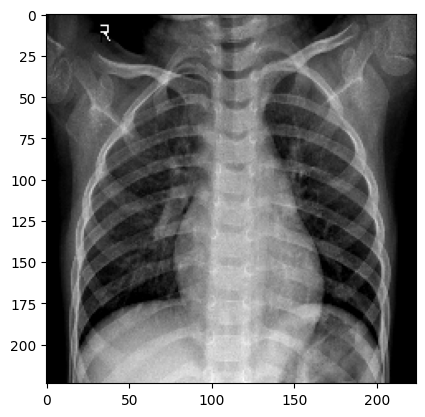

In [23]:
# View a sample Test Image
# Prints the human-readable label of the first image in the test batch.
print(INV_LABELS[label[0].numpy()])
# Displays the first image from the test batch using Matplotlib.
plt.imshow(image[0].numpy().reshape(224 , 224 , 3))

In [24]:
# Evaluating the loaded model
# `loaded_model.evaluate` computes the loss and metrics for the model on the test dataset.
# It returns the values in the order defined during `model.compile`.
# `loss`: The final loss value on the test set.
# `acc`: The final accuracy on the test set.
# `prec`: The final precision on the test set.
# `rec`: The final recall on the test set.
loss, acc, prec, rec = loaded_model.evaluate(test_dataset)

# Prints the evaluation metrics for the test set.
print(" Testing Acc : " , acc)
print(" Testing Precision " , prec)
print(" Testing Recall " , rec)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 0.0619 - precision: 1.0000 - recall: 1.0000
 Testing Acc :  1.0
 Testing Precision  1.0
 Testing Recall  1.0
